# Osteoarthritis scRNA-seq Analysis

In [36]:
import warnings
warnings.filterwarnings("ignore")

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

## Overview

This analysis investigates how osteoarthritis alters cellular composition in joint tissues using single-cell RNA sequencing data. 

We cluster cells into distinct states and examine how these states differ between diseased and less diseased tissue.

## Load Data

In [22]:
adata = sc.read("../artifacts/scRNA/clustered.h5ad")

## UMAP: Cell Clusters

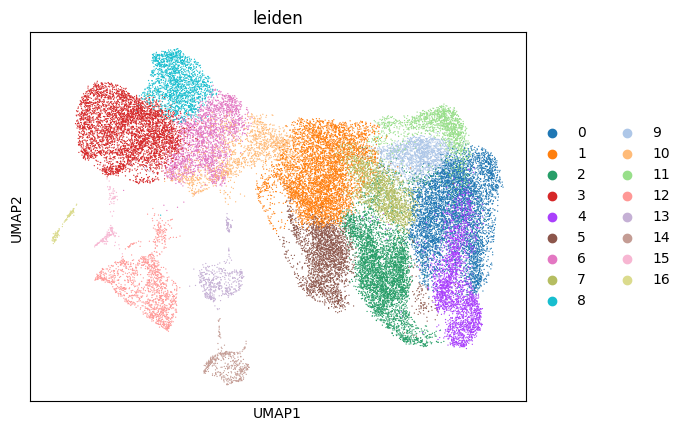

In [23]:
sc.pl.umap(adata, color='leiden')

In [24]:
print(adata.obs['leiden'].value_counts())
print("Number of clusters:", adata.obs['leiden'].nunique())

leiden
0     5435
1     4630
2     4309
3     4269
4     2508
5     2412
6     2239
7     1772
8     1740
9     1530
10    1409
11    1372
12    1365
13     511
14     425
15     153
16     126
Name: count, dtype: int64
Number of clusters: 17


## UMAP: Disease Condition

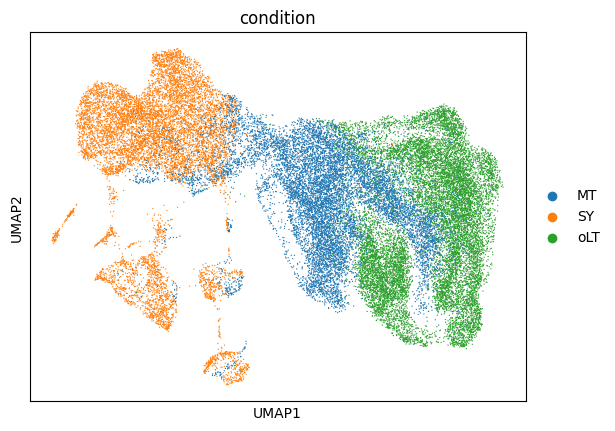

In [25]:
sc.pl.umap(adata, color='condition')

## Cluster Distribution Across Conditions

In [ ]:
pd.crosstab(
    adata.obs['leiden'],
    adata.obs['condition'],
    normalize='columns'
)

condition,MT,SY,oLT
leiden,,,
0,0.086876,0.000000,0.305725
1,0.353666,0.000097,0.041996
2,0.030191,0.000000,0.272596
3,0.014083,0.399126,0.000000
4,0.002465,0.000000,0.170458
5,0.203943,0.000000,0.006530
6,0.017956,0.197669,0.000000
7,0.145234,0.000000,0.008385
8,0.000264,0.168723,0.000000


## Cluster Marker Genes

In [30]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

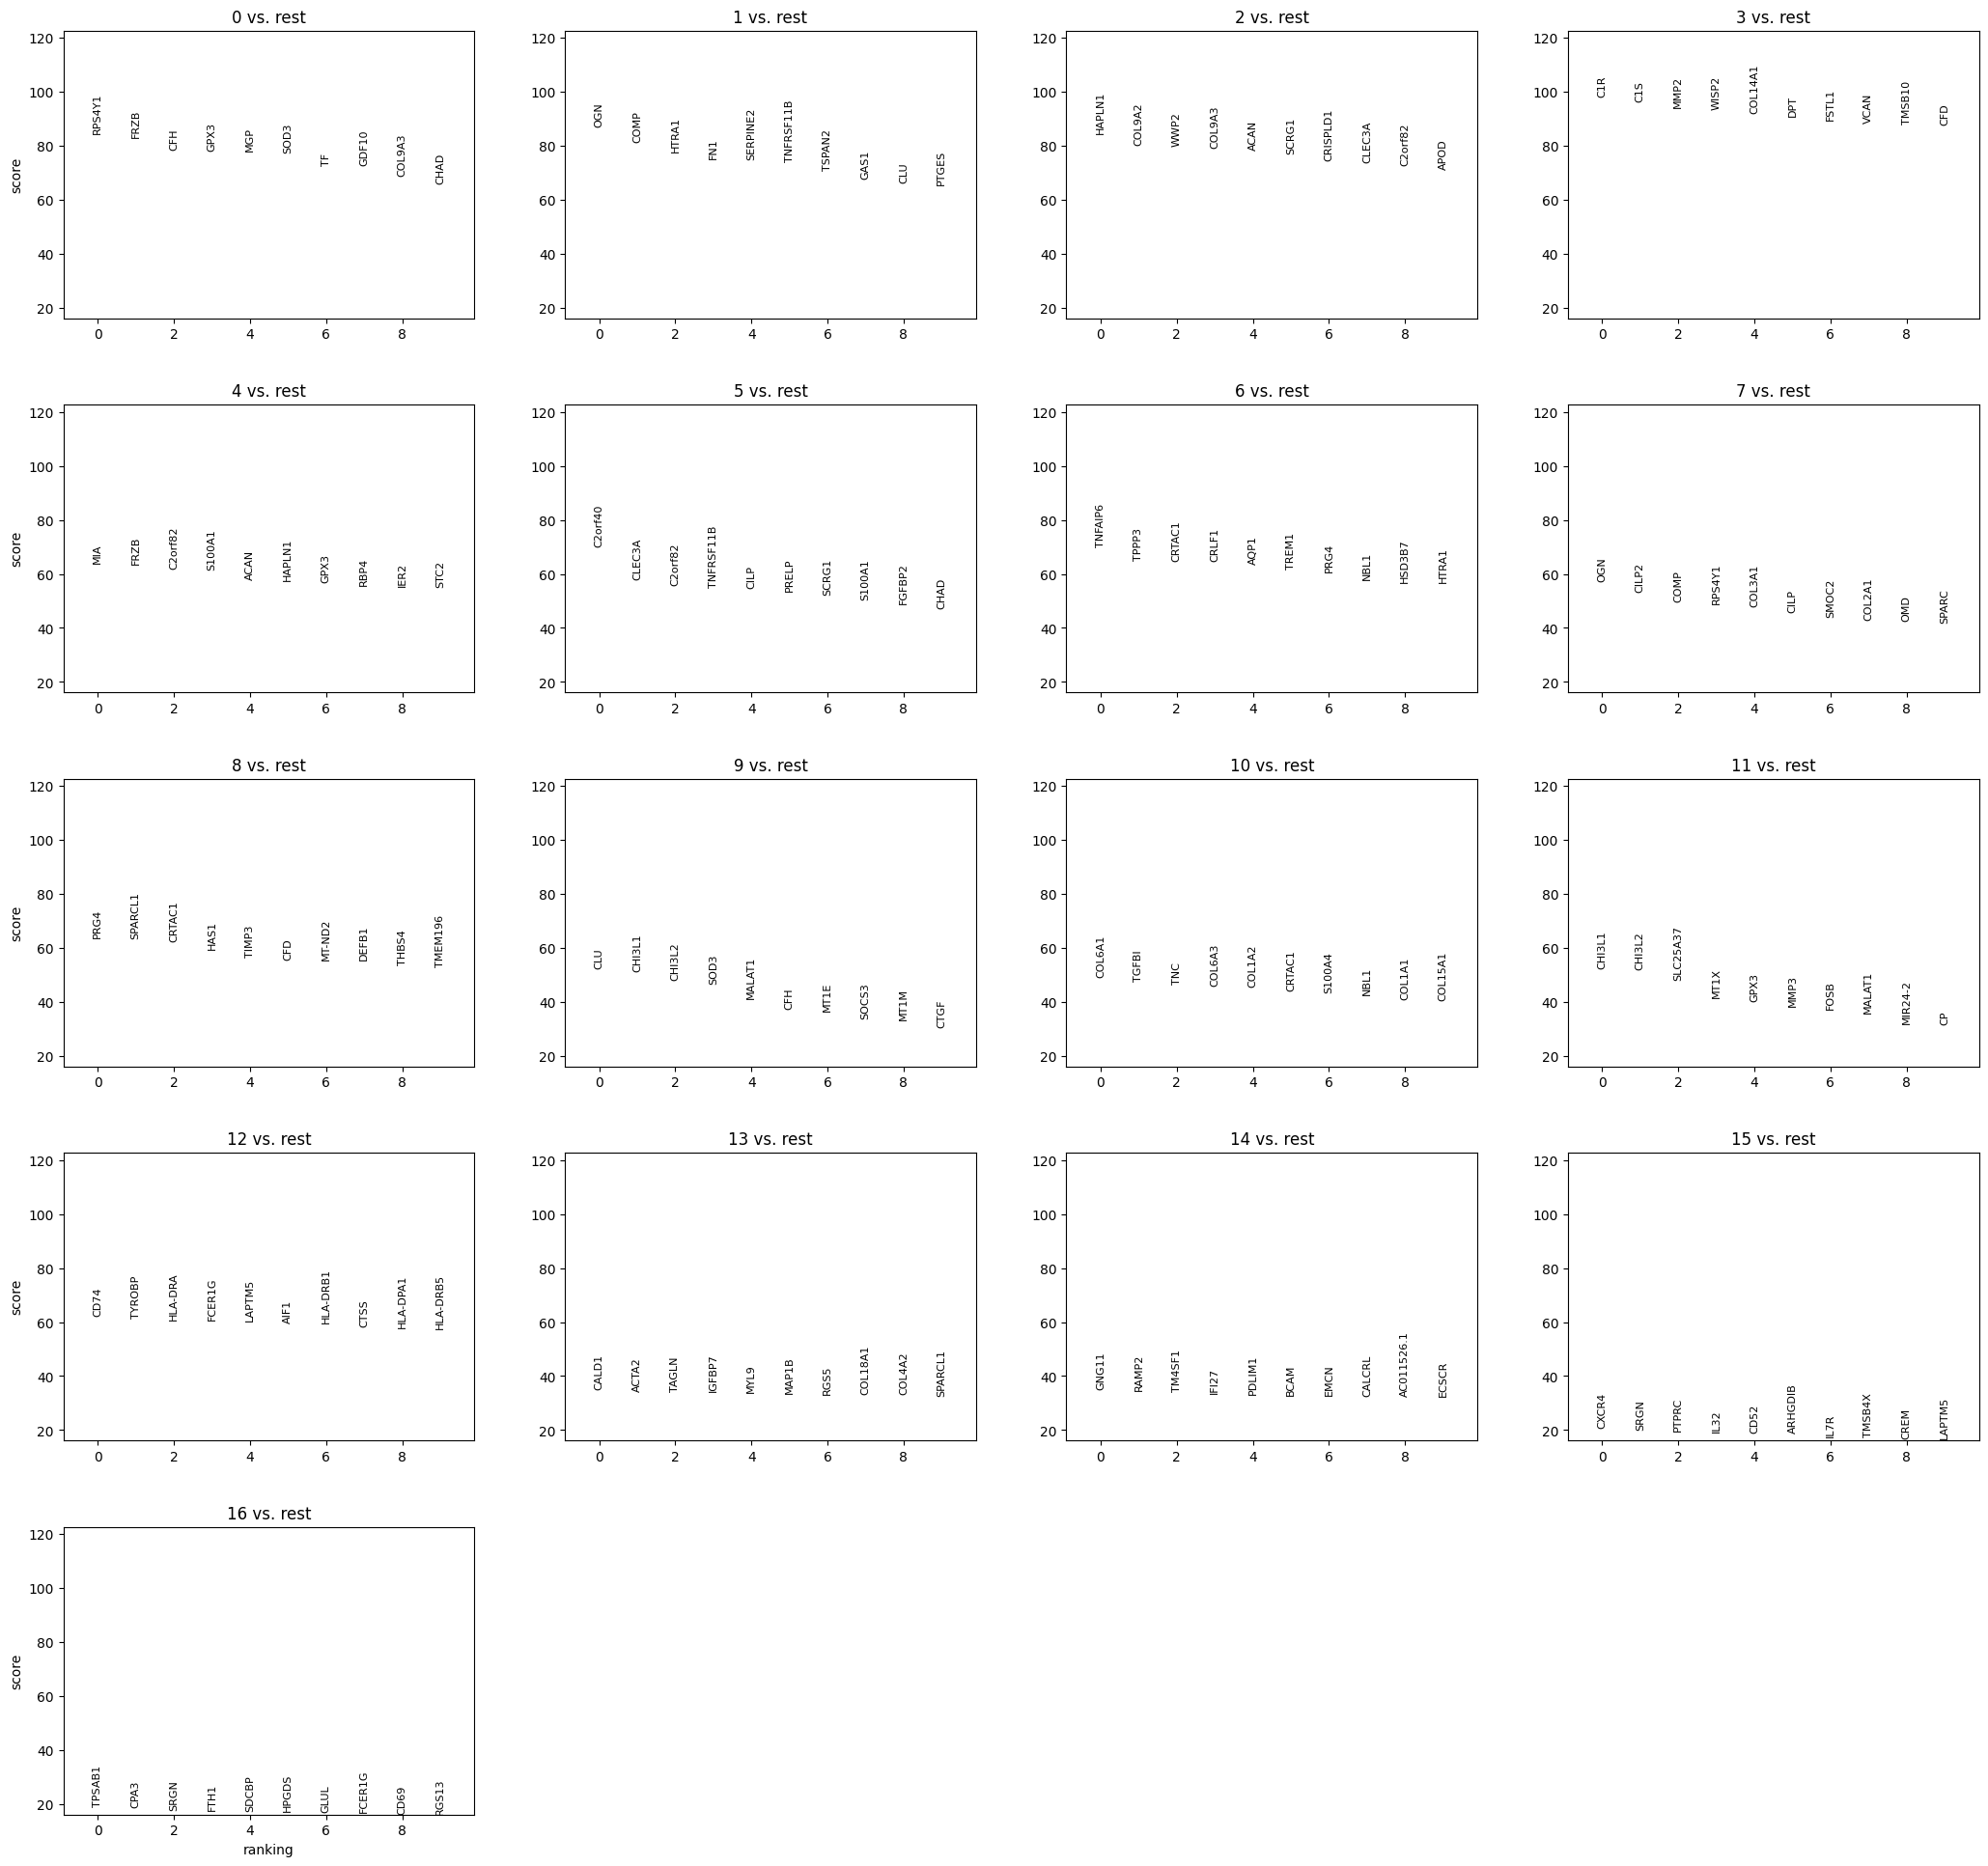

In [31]:
sc.pl.rank_genes_groups(adata, n_genes=10)

## Cluster 1: Degenerative Chondrocyte State

In [ ]:
cluster = '1'
genes = adata.uns['rank_genes_groups']['names'][cluster][:15]
print(genes)

### Interpretation

Cluster 1 is enriched in osteoarthritic cartilage (MT) and is characterized by high expression of extracellular matrix and remodeling genes, including COMP, FN1, COL15A1, and TGFBI.

Additionally, genes such as HTRA1 and PTGES suggest active tissue degradation and inflammatory signaling.

This cluster likely represents a degenerative chondrocyte state associated with cartilage breakdown and remodeling in osteoarthritis.

## Cluster 0: Homeostatic Cartilage State

In [35]:
cluster = '0'
print(adata.uns['rank_genes_groups']['names'][cluster][:15])

['RPS4Y1' 'FRZB' 'CFH' 'GPX3' 'MGP' 'SOD3' 'TF' 'GDF10' 'COL9A3' 'CHAD'
 'SERPINA1' 'DDX3Y' 'DDIT3' 'MT1E' 'MIA']


### Interpretation

Cluster 0 is enriched in less diseased cartilage (oLT) and is characterized by expression of canonical cartilage genes such as COL9A3, CHAD, and MIA.

The presence of antioxidant and regulatory genes including SOD3 and GPX3 suggests a protective, low-stress cellular environment.

This cluster likely represents a homeostatic chondrocyte state associated with healthy cartilage maintenance.

## Quantifying OA as a Cell-State Shift

To move beyond qualitative cluster interpretation, we define a sample-level OA score based on the relative abundance of disease-associated and homeostatic cell states.

As an initial score, we use the difference between the proportion of cells in:
- Cluster 1 (degenerative / OA-associated)
- Cluster 0 (homeostatic / healthy)

In [37]:
cluster_props = pd.crosstab(
    adata.obs['sample'],
    adata.obs['leiden'],
    normalize='index'
)

cluster_props.head()

leiden,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
sample,,,,,,,,,,,,,,,,,
GSM4626763_SY_113,0.000000,0.000000,0.000000,0.516289,0.000000,0.000000,0.079261,0.000000,0.251887,0.000596,0.001391,0.000000,0.074295,0.019865,0.024434,0.015693,0.016289
GSM4626764_SY_116,0.000000,0.000265,0.000000,0.320720,0.000000,0.000000,0.427891,0.000000,0.065097,0.000000,0.017730,0.000000,0.085737,0.048426,0.022493,0.002911,0.008732
GSM4626765_SY_118,0.000000,0.000000,0.000000,0.201080,0.000000,0.000000,0.012821,0.000000,0.150472,0.000675,0.000000,0.000000,0.414305,0.059379,0.111336,0.042510,0.007422
GSM4626766_OA_oLT_113,0.710110,0.013404,0.004683,0.000000,0.050388,0.000969,0.000000,0.017119,0.000000,0.195252,0.001130,0.006783,0.000000,0.000000,0.000161,0.000000,0.000000
GSM4626767_OA_oLT_116,0.008995,0.062963,0.007937,0.000000,0.569577,0.001323,0.000000,0.003175,0.000000,0.003439,0.001587,0.339683,0.000794,0.000265,0.000265,0.000000,0.000000


In [38]:
sample_conditions = adata.obs[['sample', 'condition']].drop_duplicates()
sample_conditions = sample_conditions.set_index('sample')

cluster_props = cluster_props.join(sample_conditions)

cluster_props

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,condition
sample,,,,,,,,,,,,,,,,,,
GSM4626763_SY_113,0.000000,0.000000,0.000000,0.516289,0.000000,0.000000,0.079261,0.000000,0.251887,0.000596,0.001391,0.000000,0.074295,0.019865,0.024434,0.015693,0.016289,SY
GSM4626764_SY_116,0.000000,0.000265,0.000000,0.320720,0.000000,0.000000,0.427891,0.000000,0.065097,0.000000,0.017730,0.000000,0.085737,0.048426,0.022493,0.002911,0.008732,SY
GSM4626765_SY_118,0.000000,0.000000,0.000000,0.201080,0.000000,0.000000,0.012821,0.000000,0.150472,0.000675,0.000000,0.000000,0.414305,0.059379,0.111336,0.042510,0.007422,SY
GSM4626766_OA_oLT_113,0.710110,0.013404,0.004683,0.000000,0.050388,0.000969,0.000000,0.017119,0.000000,0.195252,0.001130,0.006783,0.000000,0.000000,0.000161,0.000000,0.000000,oLT
GSM4626767_OA_oLT_116,0.008995,0.062963,0.007937,0.000000,0.569577,0.001323,0.000000,0.003175,0.000000,0.003439,0.001587,0.339683,0.000794,0.000265,0.000265,0.000000,0.000000,oLT
GSM4626768_OA_oLT_118,0.003714,0.063360,0.853616,0.000000,0.003277,0.018353,0.000000,0.000874,0.000000,0.050251,0.001966,0.004370,0.000000,0.000218,0.000000,0.000000,0.000000,oLT
GSM4626769_OA_MT_113,0.313060,0.042894,0.000640,0.000000,0.003201,0.041293,0.000000,0.524328,0.000000,0.019526,0.053137,0.000000,0.000000,0.001921,0.000000,0.000000,0.000000,MT
GSM4626770_OA_MT_116,0.002622,0.279348,0.004078,0.046606,0.004369,0.196038,0.059423,0.003204,0.000874,0.000291,0.330615,0.006117,0.014565,0.037285,0.014565,0.000000,0.000000,MT
GSM4626771_OA_MT_118,0.000000,0.608868,0.068068,0.000000,0.000624,0.315362,0.000000,0.000208,0.000000,0.002498,0.002498,0.001041,0.000000,0.000833,0.000000,0.000000,0.000000,MT


In [39]:
cluster_props['oa_score_v1'] = cluster_props['1'] - cluster_props['0']

cluster_props[['condition', '0', '1', 'oa_score_v1']]

,condition,0,1,oa_score_v1
sample,,,,
GSM4626763_SY_113,SY,0.000000,0.000000,0.000000
GSM4626764_SY_116,SY,0.000000,0.000265,0.000265
GSM4626765_SY_118,SY,0.000000,0.000000,0.000000
GSM4626766_OA_oLT_113,oLT,0.710110,0.013404,-0.696705
GSM4626767_OA_oLT_116,oLT,0.008995,0.062963,0.053968
GSM4626768_OA_oLT_118,oLT,0.003714,0.063360,0.059646
GSM4626769_OA_MT_113,MT,0.313060,0.042894,-0.270166
GSM4626770_OA_MT_116,MT,0.002622,0.279348,0.276726
GSM4626771_OA_MT_118,MT,0.000000,0.608868,0.608868


In [40]:
cluster_props.groupby('condition')['oa_score_v1'].mean()

condition
MT     0.205142
SY     0.000088
oLT   -0.194364
Name: oa_score_v1, dtype: float64

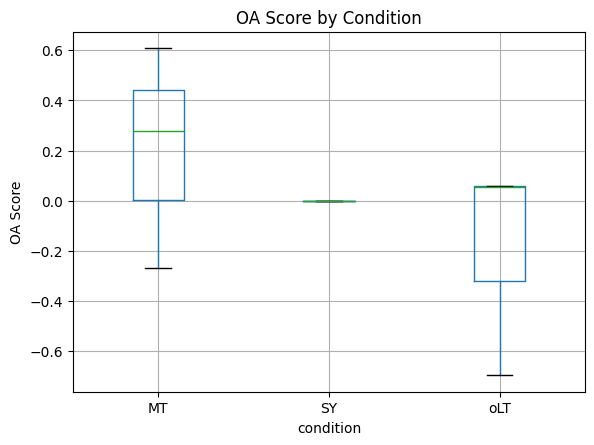

In [41]:
cluster_props.boxplot(column='oa_score_v1', by='condition')
plt.suptitle("")
plt.title("OA Score by Condition")
plt.ylabel("OA Score")
plt.show()

## OA Score Results

The OA score shows a clear separation between conditions.

- Osteoarthritic cartilage (MT) has a high positive score, indicating enrichment of the degenerative cell state.
- Less diseased cartilage (oLT) has a negative score, reflecting enrichment of the homeostatic state.
- Synovial tissue (SY) lies near zero, consistent with a distinct cellular identity.

This demonstrates that osteoarthritis can be quantified as a shift in the relative abundance of specific cell states.

## Improved OA Score (Multi-Cluster)

To better capture disease-associated heterogeneity, we extend the OA score to include multiple clusters.

Clusters enriched in diseased cartilage (MT):
- 1, 5, 7, 10

Clusters enriched in less diseased cartilage (oLT):
- 0, 2, 4, 11

In [44]:
cluster_props['oa_score_v2'] = (
    cluster_props[['1','5','7','10']].sum(axis=1)
    - cluster_props[['0','2','4','11']].sum(axis=1)
)

In [45]:
cluster_props.groupby('condition')['oa_score_v2'].mean()

condition
MT     0.664657
SY     0.006462
oLT   -0.792303
Name: oa_score_v2, dtype: float64

In [50]:
cluster_props[['condition', 'oa_score_v2']].to_csv(
    "../artifacts/scRNA/oa_scores.csv"
)

## Improved OA Score Results

The multi-cluster OA score shows a strong separation between conditions.

- Osteoarthritic cartilage (MT) has a high positive score, reflecting enrichment of multiple degenerative and remodeling cell states.
- Less diseased cartilage (oLT) has a strongly negative score, indicating dominance of homeostatic cell states.
- Synovial tissue (SY) remains near zero, consistent with a distinct cellular identity.

Compared to the single-cluster score, this refined score captures disease-associated heterogeneity more effectively and provides a more robust quantitative measure of osteoarthritis.

## Conclusion

The analysis reveals that osteoarthritis is associated with a shift in cell state composition.

Less diseased cartilage (oLT) is dominated by homeostatic chondrocytes characterized by stable extracellular matrix expression and protective signaling.

In contrast, osteoarthritic cartilage (MT) is enriched in a degenerative chondrocyte state marked by extracellular matrix remodeling, fibrosis, and stress-related pathways.

These findings suggest that osteoarthritis progression is driven by the emergence of pathological cell states rather than a uniform change across all cells.